# Model Training

In [1]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
import sys
import os

# Obtener la ruta base del proyecto
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))

# Agregar "src" al path
sys.path.append(os.path.join(BASE_DIR, "src"))

import modelsImplementation


In [3]:
data = pd.read_csv(os.path.join("../data/ml/Airbnb_Data_Cleaned.csv"))

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59463 entries, 0 to 59462
Data columns (total 74 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   log_price                            59463 non-null  float64
 1   accommodates                         59463 non-null  int64  
 2   bathrooms                            59463 non-null  float64
 3   cleaning_fee                         59463 non-null  int64  
 4   host_has_profile_pic                 59463 non-null  int64  
 5   host_identity_verified               59463 non-null  int64  
 6   host_response_rate                   59463 non-null  float64
 7   instant_bookable                     59463 non-null  int64  
 8   latitude                             59463 non-null  float64
 9   longitude                            59463 non-null  float64
 10  number_of_reviews                    59463 non-null  int64  
 11  review_scores_rating        

In [5]:
# Separa los datos en train, test y validation con sklearn
from sklearn.model_selection import train_test_split

train, test = train_test_split(data, test_size=0.2, random_state=42)
train, validation = train_test_split(train, test_size=0.2, random_state=42)

In [6]:
# x es todo menos la primera columna
x_train = train.iloc[:, 1:].values
x_test = test.iloc[:, 1:].values
x_validation = validation.iloc[:, 1:].values    
# y es la primera columna
y_train = train.iloc[:, 0].values
y_test = test.iloc[:, 0].values
y_validation = validation.iloc[:, 0].values

In [7]:
# Print los shapes
print("x_train shape: ", x_train.shape)
print("x_validation shape: ", x_validation.shape)
print("x_test shape: ", x_test.shape)
print("y_train shape: ", y_train.shape)
print("y_validation shape: ", y_validation.shape)
print("y_test shape: ", y_test.shape)

x_train shape:  (38056, 73)
x_validation shape:  (9514, 73)
x_test shape:  (11893, 73)
y_train shape:  (38056,)
y_validation shape:  (9514,)
y_test shape:  (11893,)


In [8]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)
x_validation = scaler.transform(x_validation)

In [9]:
y_train

array([5.00394631, 4.38202663, 4.17438727, ..., 3.73766962, 4.78749174,
       3.93182563])

In [10]:
# Crea una función para MSE, RMSE, MAE, R2
def metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(y_true - y_pred))
    r2 = 1 - (np.sum((y_true - y_pred) ** 2) / np.sum((y_true - np.mean(y_true)) ** 2))
    print("MSE: ", mse)
    print("RMSE: ", rmse)
    print("MAE: ", mae)
    print("R2: ", r2)
    return mse, rmse, mae, r2

In [11]:
metricas = {'LinearRegressionNormalEquation': [], 'LinearRegressionSVD': [], 'LinearRegressionBatchGD': [], 'LinearRegressionSGD': [], 'SGDRegressor': [], 'PolynomialRegression': [], 'LinealRegression': [], 'Lasso': [], 'Ridge': []}

## PCA

In [12]:
# Convierte los tensores a arrays de numpy
x_train_np = np.array(x_train)
x_val_np = np.array(x_validation)
x_test_np = np.array(x_test)

In [13]:
# Ajusta el PCA nuevamente con el número de componentes
pca = PCA(n_components=0.8)
x_train_pca = pca.fit_transform(x_train_np)
x_validation_pca = pca.transform(x_val_np)
x_test_pca = pca.transform(x_test_np)

In [14]:
# Verifica las nuevas formas de los datos
print(x_train.shape)
print(x_validation.shape)
print(x_test.shape)

(38056, 73)
(9514, 73)
(11893, 73)


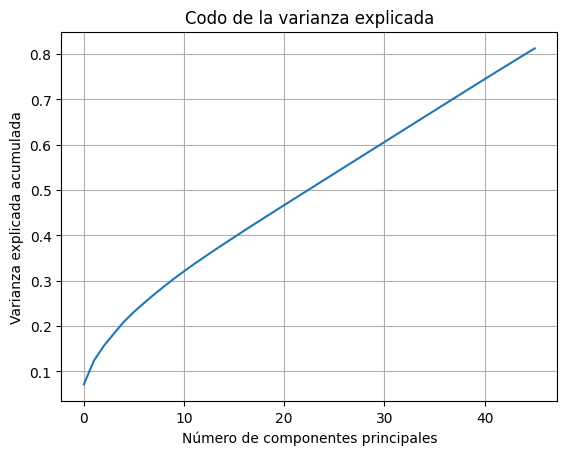

In [15]:
# Varianza explicada acumulada
explained_variance = np.cumsum(pca.explained_variance_ratio_)

plt.plot(explained_variance)
plt.xlabel('Número de componentes principales')
plt.ylabel('Varianza explicada acumulada')
plt.title('Codo de la varianza explicada')
plt.grid(True)
plt.show()

## LinearRegressionNormalEquation

In [16]:
from modelsImplementation import LinearRegressionNormalEquation as LRNE
LRNE_model = LRNE()
LRNE_model.fit(x_train, y_train)
y_val_pred = LRNE_model.predict(x_validation)
y_test_pred = LRNE_model.predict(x_test)

In [17]:
print('Test')
mse, rmse, mae, r2 = metrics(y_test, y_test_pred)
test_metrics = [mse, rmse, mae, r2]
print('Validation')
mse, rmse, mae, r2 = metrics(y_validation, y_val_pred)
val_metrics = [mse, rmse, mae, r2]
metricas['LinearRegressionNormalEquation'] = [test_metrics, val_metrics]

Test
MSE:  0.17675923875255503
RMSE:  0.4204274476679122
MAE:  0.6255231819907726
R2:  -18393.08964678811
Validation
MSE:  0.1765196105374217
RMSE:  0.420142369367125
MAE:  0.6281068471560688
R2:  -14804.718990787542


In [18]:
# LinearRegressionNormalEquation con sklearn
from sklearn.linear_model import LinearRegression

# Entrena el modelo
model = LinearRegression()
model.fit(x_train, y_train)

# Predice los valores de validación y test
y_val_pred = model.predict(x_validation)
y_test_pred = model.predict(x_test)

In [19]:
print('Test')
mse, rmse, mae, r2 = metrics(y_test, y_test_pred)
test_metrics = [mse, rmse, mae, r2]
print('Validation')
mse, rmse, mae, r2 = metrics(y_validation, y_val_pred)
val_metrics = [mse, rmse, mae, r2]
metricas['LinealRegression'] = [test_metrics, val_metrics]


Test
MSE:  0.17675923875308988
RMSE:  0.4204274476685483
MAE:  0.3259956830141703
R2:  0.5490042255712019
Validation
MSE:  0.17651961053873283
RMSE:  0.4201423693686853
MAE:  0.3232030896986593
R2:  0.5511778447948161


## Regresión Lineal con Singular Value Decomposition

In [20]:
from modelsImplementation import LinearRegressionSVD as LRSVD
# LinearRegressionSVD
LRSVD_model = LRSVD()
LRSVD_model.fit(x_train, y_train)
y_val_pred = LRSVD_model.predict(x_validation)
y_test_pred = LRSVD_model.predict(x_test)

In [21]:
print('Test')
mse, rmse, mae, r2 = metrics(y_test, y_test_pred)
test_metrics = [mse, rmse, mae, r2]
print('Validation')
mse, rmse, mae, r2 = metrics(y_validation, y_val_pred)
val_metrics = [mse, rmse, mae, r2]
metricas['LinearRegressionSVD'] = [test_metrics, val_metrics]

Test
MSE:  4.4211385982845736e+23
RMSE:  664916430710.249
MAE:  6097072447.536651
R2:  -1.1280399486080879e+24
Validation
MSE:  0.17819671448078303
RMSE:  0.422133526838112
MAE:  0.32434985675266936
R2:  0.5469136080707673


## Regresión Polinomial

In [22]:
# Polinomial Regression
from sklearn.preprocessing import PolynomialFeatures

# Crea los polinomios
poly = PolynomialFeatures(degree=2)
x_train_poly = poly.fit_transform(x_train)
x_val_poly = poly.transform(x_validation)
x_test_poly = poly.transform(x_test)

# Entrena el modelo
model = LinearRegression()

model.fit(x_train_poly, y_train)

# Predice los valores de validación y test
y_val_pred = model.predict(x_val_poly)
y_test_pred = model.predict(x_test_poly)

In [23]:
print('Test')
mse, rmse, mae, r2 = metrics(y_test, y_test_pred)
test_metrics = [mse, rmse, mae, r2]
print('Validation')
mse, rmse, mae, r2 = metrics(y_validation, y_val_pred)
val_metrics = [mse, rmse, mae, r2]
metricas['PolynomialRegression'] = [test_metrics, val_metrics]

Test
MSE:  2.8600621072733037
RMSE:  1.6911718148293815
MAE:  0.3503829356625606
R2:  -6.2973607155322515
Validation
MSE:  3.2872615196754613
RMSE:  1.813080671033548
MAE:  0.3523264763278129
R2:  -7.358254334920309


## Regresión Lineal con Batch Gradient Descent

In [24]:
from modelsImplementation import LinearRegressionBatchGD as LRBGD
# LinearRegressionBatchGD
LRBGD_model = LRBGD(
    learning_rate=1e-3,
    n_iterations=10000
)
LRBGD_model.fit(x_train, y_train)
y_val_pred = LRBGD_model.predict(x_validation)
y_test_pred = LRBGD_model.predict(x_test)

In [25]:
# Metricas 
print('Test')
mse, rmse, mae, r2 = metrics(y_test, y_test_pred)
test_metrics = [mse, rmse, mae, r2]
print('Validation')
mse, rmse, mae, r2 = metrics(y_validation, y_val_pred)
val_metrics = [mse, rmse, mae, r2]
metricas['LinearRegressionBatchGD'] = [test_metrics, val_metrics]

Test
MSE:  0.18954380978872973
RMSE:  0.4353662938133012
MAE:  0.3393531394398101
R2:  0.5163847848243879
Validation
MSE:  0.19291874117948268
RMSE:  0.43922516000279704
MAE:  0.340797396679499
R2:  0.5094810999673758


In [26]:
# SGD 
from sklearn.linear_model import SGDRegressor

# Entrena el modelo
model = SGDRegressor(
    max_iter=500,
    tol=1e-6,
    learning_rate="adaptive",
    eta0=1,
    n_iter_no_change=1000,
    random_state=42
)

model.fit(x_train, y_train)

# Predice los valores de validación y test
y_val_pred = model.predict(x_validation)
y_test_pred = model.predict(x_test)

/Users/mateoherrera/anaconda3/envs/dataMining/lib/python3.9/site-packages/sklearn/linear_model/_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


In [27]:
# metricas 
print('Test')
mse, rmse, mae, r2 = metrics(y_test, y_test_pred)
test_metrics = [mse, rmse, mae, r2]
print('Validation')
mse, rmse, mae, r2 = metrics(y_validation, y_val_pred)
val_metrics = [mse, rmse, mae, r2]
metricas['SGDRegressor'] = [test_metrics, val_metrics]

Test
MSE:  1.6816680594019767e+28
RMSE:  129679144792135.97
MAE:  27468682096735.66
R2:  -4.290724457359719e+28
Validation
MSE:  2.853517203564446e+28
RMSE:  168923568620972.66
MAE:  27309470243955.14
R2:  -7.255407698386244e+28


## Regresión Lineal con Stochastic Gradient Descent 

In [28]:
from modelsImplementation import LinearRegressionSGD as LRSGD
# LinearRegressionSGD
LRSGD_model = LRSGD(
    epochs = 500,
    learning_rate = 0.01,
    lr_init_sch=5, 
    lr_end_sch=50, 
    tol=1e-6
)
LRSGD_model.fit(x_train, y_train)
y_val_pred = LRSGD_model.predict(x_validation)
y_test_pred = LRSGD_model.predict(x_test)

In [29]:
y_val_pred

array([[0.80808186],
       [1.18210079],
       [0.78742434],
       ...,
       [1.14999981],
       [0.9021007 ],
       [1.71462067]])

In [30]:
# Metrics
print('Test')
mse, rmse, mae, r2 = metrics(y_test, y_test_pred)
test_metrics = [mse, rmse, mae, r2]
print('Validation')
mse, rmse, mae, r2 = metrics(y_validation, y_val_pred)
val_metrics = [mse, rmse, mae, r2]
metricas['LinearRegressionSGD'] = [test_metrics, val_metrics]

Test
MSE:  13.340930943402018
RMSE:  3.652523914145124
MAE:  3.6162262778970873
R2:  -410334.6897424376
Validation
MSE:  13.337626360883567
RMSE:  3.6520715163977235
MAE:  3.6157665444942477
R2:  -327051.22283781046


## Lasso and Ridge

In [31]:
# Lasso 
from sklearn.linear_model import Lasso, LassoCV

# Entrena el modelo
model = LassoCV(alphas=[0.01, 0.1, 1, 10, 100])
model.fit(x_train, y_train)
print(model.alpha_)

# Predice los valores de validación y test
y_val_pred = model.predict(x_validation)
y_test_pred = model.predict(x_test)

0.01


In [32]:
# Metrics
print('Test')
mse, rmse, mae, r2 = metrics(y_test, y_test_pred)
test_metrics = [mse, rmse, mae, r2]
print('Validation')
mse, rmse, mae, r2 = metrics(y_validation, y_val_pred)
val_metrics = [mse, rmse, mae, r2]
metricas['Lasso'] = [test_metrics, val_metrics]

Test
MSE:  0.18421067936391364
RMSE:  0.42919771593510797
MAE:  0.33520153785273143
R2:  0.5299921034745292
Validation
MSE:  0.18611800219090538
RMSE:  0.43141395688005435
MAE:  0.33433454278632174
R2:  0.5267727896585415


In [33]:
# Ridge
from sklearn.linear_model import Ridge, RidgeCV

# Entrena el modelo
model = RidgeCV(alphas=[0.01, 0.1, 1, 10, 100])
model.fit(x_train, y_train)

# Predice los valores de validación y test
y_val_pred = model.predict(x_validation)
y_test_pred = model.predict(x_test)

In [34]:
# Metrics
print('Test')
mse, rmse, mae, r2 = metrics(y_test, y_test_pred)
test_metrics = [mse, rmse, mae, r2]
print('Validation')
mse, rmse, mae, r2 = metrics(y_validation, y_val_pred)
val_metrics = [mse, rmse, mae, r2]
metricas['Ridge'] = [test_metrics, val_metrics]

Test
MSE:  0.17673521033374515
RMSE:  0.42039887051911207
MAE:  0.3260433572090628
R2:  0.5490655333459304
Validation
MSE:  0.17658102466156414
RMSE:  0.4202154502889728
MAE:  0.32332074990631154
R2:  0.5510216920654676


## Mejor modelo y Evaluación

In [35]:
# Mira el diccionario metricas y selecciona el mejor modelo
for key, value in metricas.items():
    print(key)
    print('Test')
    print(value[0])
    print('Validation')
    print(value[1])
    print('')

LinearRegressionNormalEquation
Test
[0.17675923875255503, 0.4204274476679122, 0.6255231819907726, -18393.08964678811]
Validation
[0.1765196105374217, 0.420142369367125, 0.6281068471560688, -14804.718990787542]

LinearRegressionSVD
Test
[4.4211385982845736e+23, 664916430710.249, 6097072447.536651, -1.1280399486080879e+24]
Validation
[0.17819671448078303, 0.422133526838112, 0.32434985675266936, 0.5469136080707673]

LinearRegressionBatchGD
Test
[0.18954380978872973, 0.4353662938133012, 0.3393531394398101, 0.5163847848243879]
Validation
[0.19291874117948268, 0.43922516000279704, 0.340797396679499, 0.5094810999673758]

LinearRegressionSGD
Test
[13.340930943402018, 3.652523914145124, 3.6162262778970873, -410334.6897424376]
Validation
[13.337626360883567, 3.6520715163977235, 3.6157665444942477, -327051.22283781046]

SGDRegressor
Test
[1.6816680594019767e+28, 129679144792135.97, 27468682096735.66, -4.290724457359719e+28]
Validation
[2.853517203564446e+28, 168923568620972.66, 27309470243955.14,

In [36]:
def seleccionar_mejor_modelo(metricas):
    mejor_modelo = None
    mejor_puntaje = float('-inf')
    menor_rmse = float('inf')

    for modelo, valores in metricas.items():
        mse_test, rmse_test, mae_test, r2_test = valores[0]
        mse_valid, rmse_valid, mae_valid, r2_valid = valores[1]

        # Descartar modelos con R² negativo en validación
        if r2_valid < 0:
            continue

        # Seleccionar el modelo con mejor R² en validación
        # En caso de empate, elegir el de menor RMSE en validación
        if r2_valid > mejor_puntaje or (r2_valid == mejor_puntaje and rmse_valid < menor_rmse):
            mejor_puntaje = r2_valid
            menor_rmse = rmse_valid
            mejor_modelo = modelo

    return mejor_modelo, mejor_puntaje


In [37]:
seleccionar_mejor_modelo(metricas)

('LinealRegression', 0.5511778447948161)

In [38]:
# Entrena el modelo
model = LinearRegression()
model.fit(x_train, y_train)


LinearRegression()

In [39]:
model.coef_

array([ 1.24985670e-01,  2.37448751e-02, -5.99819094e-03, -2.29050061e-03,
       -5.00782093e-04, -1.01262049e-02, -1.74215473e-02,  1.48007129e-01,
       -1.94988170e+01, -1.20495540e-02, -5.13723017e-02,  5.83600606e-02,
       -7.03741263e-03,  1.93135441e-02,  1.00210993e-02,  1.00175479e-02,
        4.69930694e-03,  2.46077519e-03, -3.83366447e-03,  1.89301933e-03,
        7.33297189e-03,  2.50079582e-03,  2.33872187e-04,  2.39031893e-02,
       -8.74376294e-03,  9.70779853e-04, -6.46965924e-04, -2.99350530e-04,
       -2.39521807e-03,  7.45550205e-03, -1.30429301e-03, -4.69177053e-03,
        4.52112505e-03,  9.49804157e-04,  2.17167813e-02,  7.10074525e-03,
        3.46944695e-18,  3.64689708e-03, -3.03791449e-03,  1.32387255e-02,
        1.40474284e-03,  5.74323567e-03,  2.62574870e-03, -2.01188945e-03,
        2.76030664e-03,  5.53859115e-03,  2.85236344e-03, -2.67339063e-01,
       -1.44022489e-01,  4.76109838e-03, -3.38475768e-04,  7.16954554e-03,
        9.35025473e-03, -

In [44]:
import math

math.e**max(model.coef_)

1.1595211622658579

In [ ]:

math.e**model.intercept_

108.55028946417315

Se puede ver que el precio base para un Airbnb es de $108. Mientras que, para el precio el que más influye es de $1.16. Por otra parte, varios valores restán al precio del Airbnb

Se decidió no utilizar PCA aunque esta implementado ya que no mejoró las métricas de ningún valor

De igual forma, se puede apreciar 

Error bajo en general

El MSE y el RMSE tienen valores relativamente bajos (~0.177 y ~0.42 respectivamente), lo que indica que el modelo tiene una buena capacidad de ajuste y no comete errores grandes en las predicciones.

Buen desempeño y estabilidad

Los valores de MSE, RMSE y MAE son casi idénticos entre test y validación, lo que indica que el modelo tiene consistencia y no está sobreajustado.
La diferencia mínima en MAE 0.325 en test vs. 0.323 en validación sugiere que el modelo es estable y generaliza bien.

Coeficiente de determinación aceptable (R²)

El R² es de aproximadamente 0.55 en ambos conjuntos, lo que significa que el modelo explica alrededor del 55% de la variabilidad de los datos.
Si bien esto indica que el modelo tiene un desempeño razonable, podría mejorarse con la inclusión de nuevas variables o el uso de modelos más complejos